<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP2-Co24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## Data Load

In [44]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import gdown

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

In [2]:
# Enlace a la carpeta de Google Drive
folder_url = 'https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln'

# Descargar la carpeta completa en un directorio específico llamado 'dataset'
print("Descargando archivos desde Google Drive...")
gdown.download_folder(folder_url, output='dataset', quiet=True, use_cookies=False)

# Cargar los archivos directamente en las variables train y test
train = pd.read_csv('dataset/adult_train.csv')
test = pd.read_csv('dataset/adult_val.csv')

# Lista de Series transofrmadas, listas para entrenar
variables_transformadas_train = []
variables_transformadas_test  = []

Descargando archivos desde Google Drive...


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [3]:
# Train

print(train.info())
display(train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [4]:
# Test

print(test.info())
display(test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15060 non-null  int64 
 1   workclass       15060 non-null  object
 2   education       15060 non-null  object
 3   marital-status  15060 non-null  object
 4   occupation      15060 non-null  object
 5   relationship    15060 non-null  object
 6   race            15060 non-null  object
 7   sex             15060 non-null  object
 8   capital-gain    15060 non-null  int64 
 9   capital-loss    15060 non-null  int64 
 10  hours-per-week  15060 non-null  int64 
 11  skill-profile   15060 non-null  object
 12  native-country  15060 non-null  object
 13  income          15060 non-null  object
dtypes: int64(4), object(10)
memory usage: 1.6+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,security_patrol_basic,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,trade_cnc_operation,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,transport_commercial_driving,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,personal_care_assistance,United-States,<=50K


- 30K registros en Train y 15K resitros en Test
- No hay nulos

### Income (Target)
Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

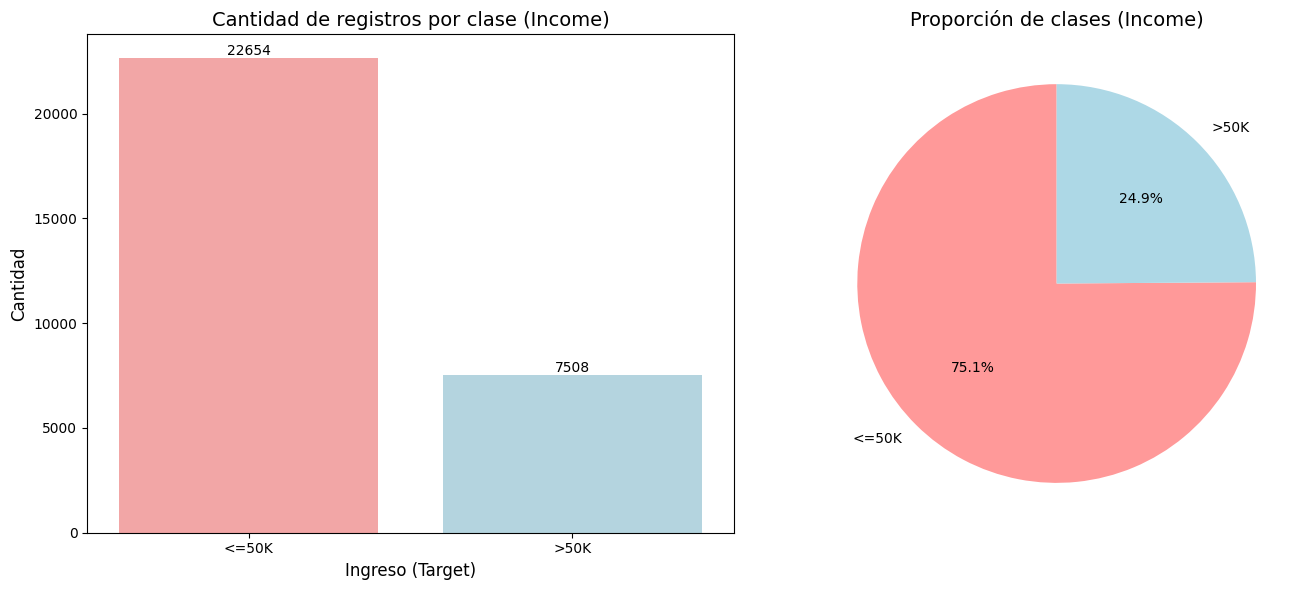

In [5]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras (Countplot)
# Se agrega hue='income' y legend=False para evitar el FutureWarning de Seaborn
sns.countplot(data=train, x='income', ax=axes[0], hue='income', palette=custom_palette, legend=False)
axes[0].set_title('Cantidad de registros por clase (Income)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

# Agregar los valores exactos sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de torta (Pie chart)
income_counts = train['income'].value_counts()
# Mapeamos los colores desde custom_palette respetando el orden del índice
pie_colors = [custom_palette[val] for val in income_counts.index]
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=90, colors=pie_colors)
axes[1].set_title('Proporción de clases (Income)', fontsize=14)

plt.tight_layout()
plt.show()

- Defino la Clase Positiva como >50K
- Un poco desbalanceada 25%

In [6]:
# 1. Transformación Variable Target (Income) -> BOOL_Income

target_mapping = {'<=50K': 0, '>50K': 1}

BOOL_Income_train = train['income'].map(target_mapping).astype(int)
BOOL_Income_test = test['income'].map(target_mapping).astype(int)

# Asignamos el nombre a la serie para consistencia
BOOL_Income_train.name = 'BOOL_Income'
BOOL_Income_test.name = 'BOOL_Income'


- Transformo el Target a INT 0/1 para el entrenamiento del modelo
- BOOL_Income

### Age
Edad del individuo expresada en años.

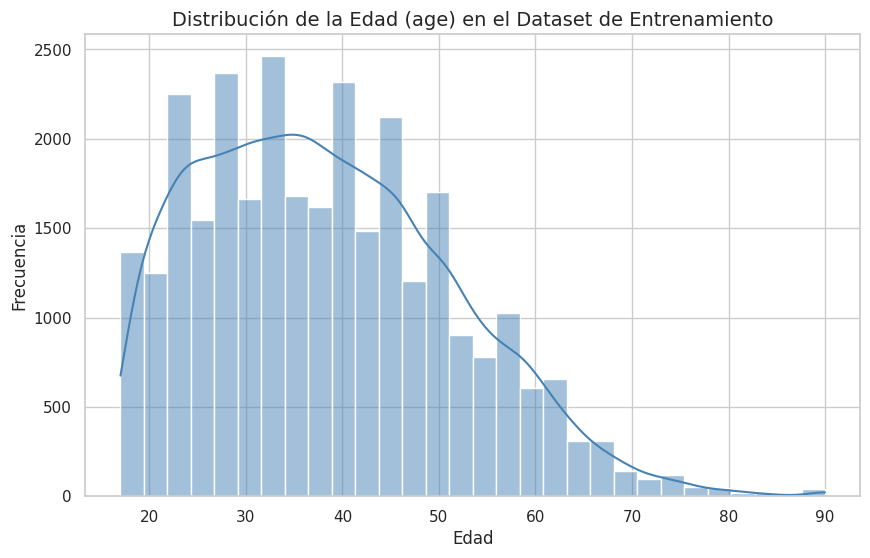


Estadísticas descriptivas de la variable 'age':


,age
count,30162.000000
mean,38.437902
std,13.134665
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,90.000000


In [7]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear el histograma para la variable 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='age', bins=30, kde=True, color='steelblue')
plt.title('Distribución de la Edad (age) en el Dataset de Entrenamiento', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Mostrar estadísticas descriptivas de la variable 'age'
print("\nEstadísticas descriptivas de la variable 'age':")
display(train['age'].describe())

- Distribucion bastante simetrica centrada en 38/37 años (media/mediana)
- Arranca en 17 y termina en 90. Talvez se pueda capear los valores maximos?

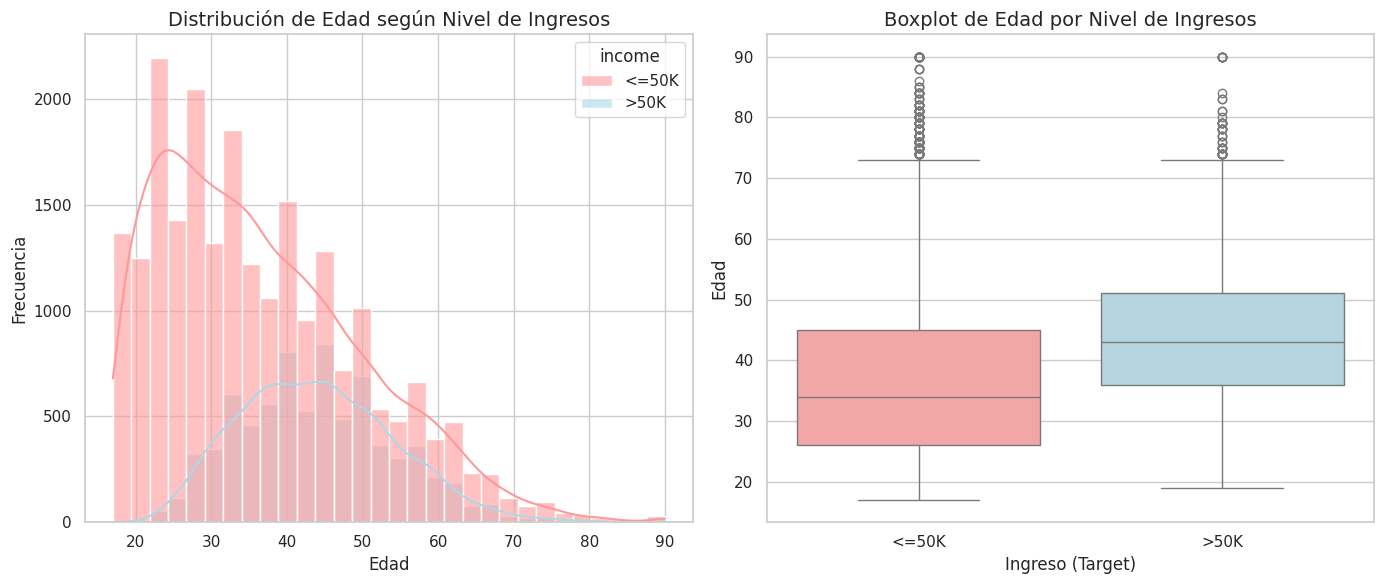

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,22654.0,36.60806,13.464631,17.0,26.0,34.0,45.0,90.0
>50K,7508.0,43.95911,10.269633,19.0,36.0,43.0,51.0,90.0


In [8]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='age', hue='income', bins=30, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Edad según Nivel de Ingresos', fontsize=14)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Edad por clase (Income)
# Se asigna hue='income' y legend=False para evitar warnings de seaborn
sns.boxplot(data=train, x='income', y='age', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Edad por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

display(train.groupby('income')['age'].describe())

- Se observa como la distribucion de la edad para el segmento de mayores ingresos es mas simetrica y centrada en 43 años, considerablmente mayor a la distribucion del Universo

In [9]:
# 2. Transformación Age -> SCA_age
upper_limit = train['age'].quantile(0.99)

# Aplicamos clipping
age_train_clipped = train['age'].clip(upper=upper_limit).values.reshape(-1, 1)
age_test_clipped = test['age'].clip(upper=upper_limit).values.reshape(-1, 1)

scaler_age = MinMaxScaler()

# Guardamos como Series independientes con el nuevo nombre SCA_age
SCA_age_train = pd.Series(scaler_age.fit_transform(age_train_clipped).flatten(), index=train.index, name='SCA_age')
SCA_age_test = pd.Series(scaler_age.transform(age_test_clipped).flatten(), index=test.index, name='SCA_age')

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(SCA_age_train)
variables_transformadas_test.append(SCA_age_test)

display(SCA_age_train.describe())


,SCA_age
count,30162.000000
mean,0.388678
std,0.235509
min,0.000000
25%,0.200000
50%,0.363636
75%,0.545455
max,1.000000


- Capeamos al percentil 99 para limitar el impacto que puedan ocacionar los registros con valores extremos (gente de 90 años)
- Ya que la idea es utilizar una Red Neuronal, y que sabemos que no hay valores exteremos, Escalamos los datos entre 0 y 1 utilizando MinMax Scaler
- SCA_age

### Workclass
Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

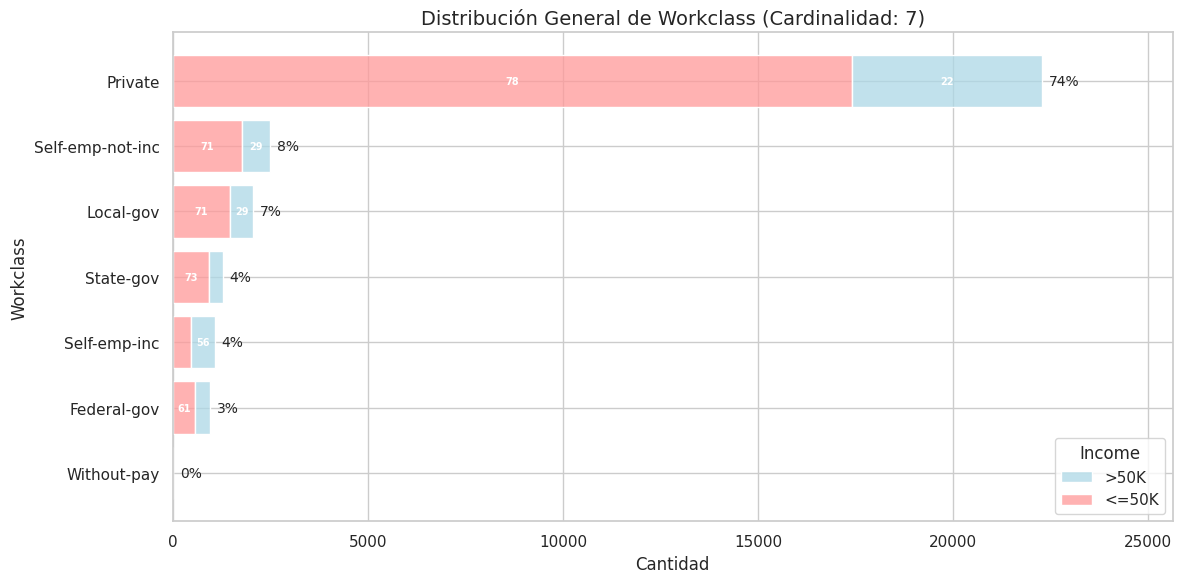

In [10]:
cardinalidad_workclass = train['workclass'].nunique()
conteo_workclass = train['workclass'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['workclass'] = pd.Categorical(train['workclass'], categories=conteo_workclass.index, ordered=True)

sns.histplot(data=train, y='workclass', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Workclass (Cardinalidad: {cardinalidad_workclass})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Workclass', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_workclass.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_workclass):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_workclass.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['workclass'] = train['workclass'].astype(object)
plt.tight_layout()
plt.show()

- Carnilaidad de 7: Probar one-hot y embeddings
- La gran mayoría de las personas trabajan en el sector privado
- Proporcionalmente, los trabajadores independientes registrados y los federales, son los que tienen un mayor salario
- Creamos categoria Others???? Que hacemos con "Without-pay"???

In [11]:
# 3. Transformación Workclass -> OHE_workclass
# Instanciamos el encoder
ohe_workclass = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos con train y transformamos ambos
workclass_ohe_train_raw = ohe_workclass.fit_transform(train[['workclass']])
workclass_ohe_test_raw = ohe_workclass.transform(test[['workclass']])

# Obtenemos las categorías originales para nombrar las columnas con el prefijo OHE_WORKCLASS_
categories = [cat.replace(' ', '_') for cat in ohe_workclass.categories_[0]]
columns_ohe = [f"OHE_WORKCLASS_{cat}" for cat in categories]

# Creamos los DataFrames resultantes
OHE_workclass_train = pd.DataFrame(workclass_ohe_train_raw, columns=columns_ohe, index=train.index)
OHE_workclass_test = pd.DataFrame(workclass_ohe_test_raw, columns=columns_ohe, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_workclass_train)
variables_transformadas_test.append(OHE_workclass_test)


- Cardinlaidad baja y no ordinal, transformamos con One-Hot encoding
- OHE_WORKCLASS_xxx


### Education
Nivel educativo alcanzado del individuo.

In [12]:
# Renombramos para que incluya el valor ordinal de cada categoria, para simplicar la comprension en las visualizaciones

education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']
education_mapping = {edu: f'{i+1:02d}-{edu}' for i, edu in enumerate(education_order)}

# Aplicamos el mapeo ordinal
train['education'] = train['education'].map(education_mapping)
test['education'] = test['education'].map(education_mapping)

# Definimos el orden para los graficos basado en los nuevos strings
order_edu = sorted(train['education'].unique())
cardinalidad_edu = train['education'].nunique()

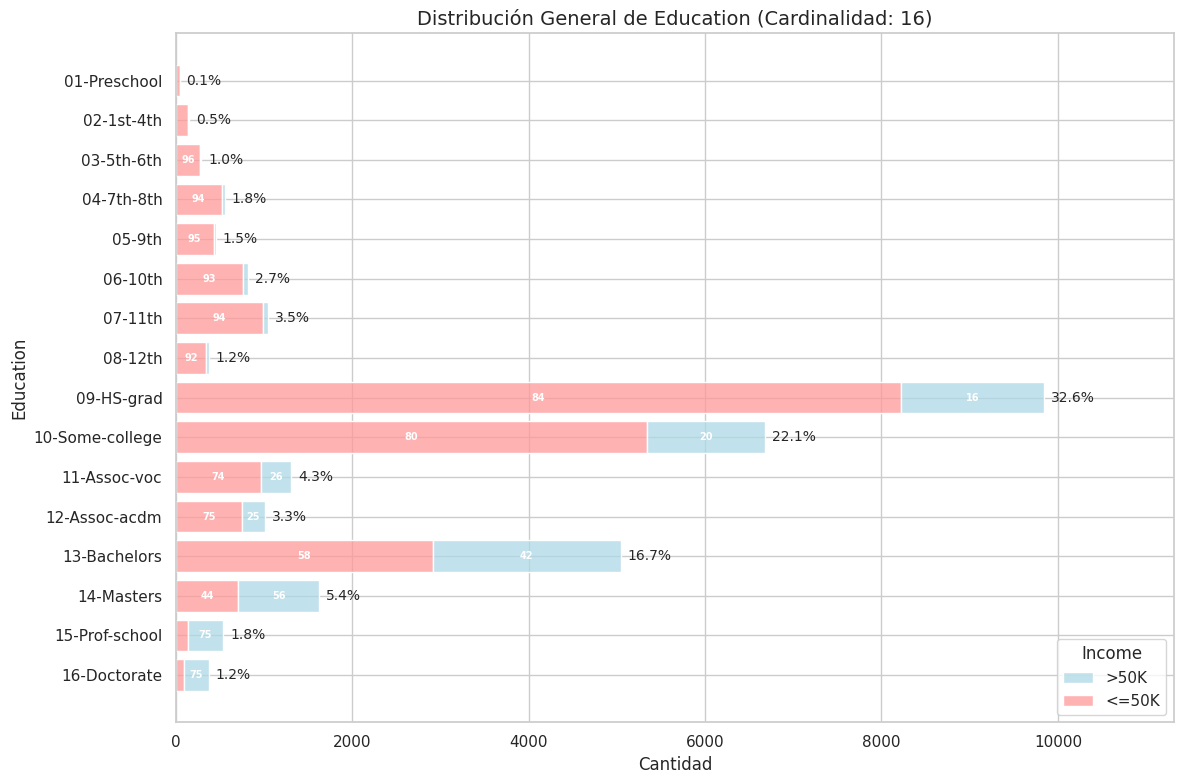

In [13]:
# Ploteo

conteo_education = train['education'].value_counts().reindex(order_edu)
fig, ax = plt.subplots(figsize=(12, 8))
train['education'] = pd.Categorical(train['education'], categories=order_edu, ordered=True)

sns.histplot(data=train, y='education', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Education (Cardinalidad: {cardinalidad_edu})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education', fontsize=12)

sns.move_legend(ax, 'lower right', title='Income')

# Anotaciones externas (% del total)
ax.set_xlim(0, conteo_education.max() * 1.15)
total_records = len(train)
for i, width in enumerate(conteo_education):
    percentage = f'{100 * width / total_records:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Anotaciones internas (% de la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_education):
            total_bar = conteo_education.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

train['education'] = train['education'].astype(object)
plt.tight_layout()
plt.show()

- Cardinlaidad de 16: Podemos usar Embeddings o agruparlas y usar Ordinal
- Se ve claramente que los profesionales con titulo universitario tienen una mayor distribucion de ingresos

In [14]:
# Agrupamos y Transoformamos

# Reagrupamos las categorías de education según lo solicitado (cubriendo ambas opciones)
group_mapping = {
    'Preschool': '01 - Primary',
    '1st-4th': '01 - Primary',
    '5th-6th': '01 - Primary',
    '7th-8th': '01 - Primary',
    '9th': '02 - HighSchool Incomplete',
    '10th': '02 - HighSchool Incomplete',
    '11th': '02 - HighSchool Incomplete',
    '12th': '02 - HighSchool Incomplete',
    'HS-grad': '03 - HighSchool Complete',
    'Some-college': '04 - Bachelors Incomplete',
    'Assoc-voc': '05 - Associate Complete',
    'Assoc-acdm': '05 - Associate Complete',
    'Bachelors': '06 - Bachelors Complete',
    'Masters': '07 - Masters Complete',
    'Prof-school': '08 - Prof/PhD Complete',
    'Doctorate': '08 - Prof/PhD Complete',
    '01-Preschool': '01 - Primary',
    '02-1st-4th': '01 - Primary',
    '03-5th-6th': '01 - Primary',
    '04-7th-8th': '01 - Primary',
    '05-9th': '02 - HighSchool Incomplete',
    '06-10th': '02 - HighSchool Incomplete',
    '07-11th': '02 - HighSchool Incomplete',
    '08-12th': '02 - HighSchool Incomplete',
    '09-HS-grad': '03 - HighSchool Complete',
    '10-Some-college': '04 - Bachelors Incomplete',
    '11-Assoc-voc': '05 - Associate Complete',
    '12-Assoc-acdm': '05 - Associate Complete',
    '13-Bachelors': '06 - Bachelors Complete',
    '14-Masters': '07 - Masters Complete',
    '15-Prof-school': '08 - Prof/PhD Complete',
    '16-Doctorate': '08 - Prof/PhD Complete'
}

# Aplicamos la agrupación limpiando espacios extras
train['education_grouped'] = train['education'].str.strip().map(group_mapping)
test['education_grouped'] = test['education'].str.strip().map(group_mapping)

# Definimos el nuevo orden
new_order = [
    '01 - Primary',
    '02 - HighSchool Incomplete',
    '03 - HighSchool Complete',
    '04 - Bachelors Incomplete',
    '05 - Associate Complete',
    '06 - Bachelors Complete',
    '07 - Masters Complete',
    '08 - Prof/PhD Complete'
]

# Creamos un mapeo inverso a enteros (0 a 7)
ord_mapping = {val: i for i, val in enumerate(new_order)}

# Aplicamos el ordinal encoding a los grupos
ORD_education_train = train['education_grouped'].map(ord_mapping).astype(int)
ORD_education_test = test['education_grouped'].map(ord_mapping).astype(int)

# Asignamos nombre para consistencia
ORD_education_train.name = 'ORD_education'
ORD_education_test.name = 'ORD_education'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(ORD_education_train)
variables_transformadas_test.append(ORD_education_test)


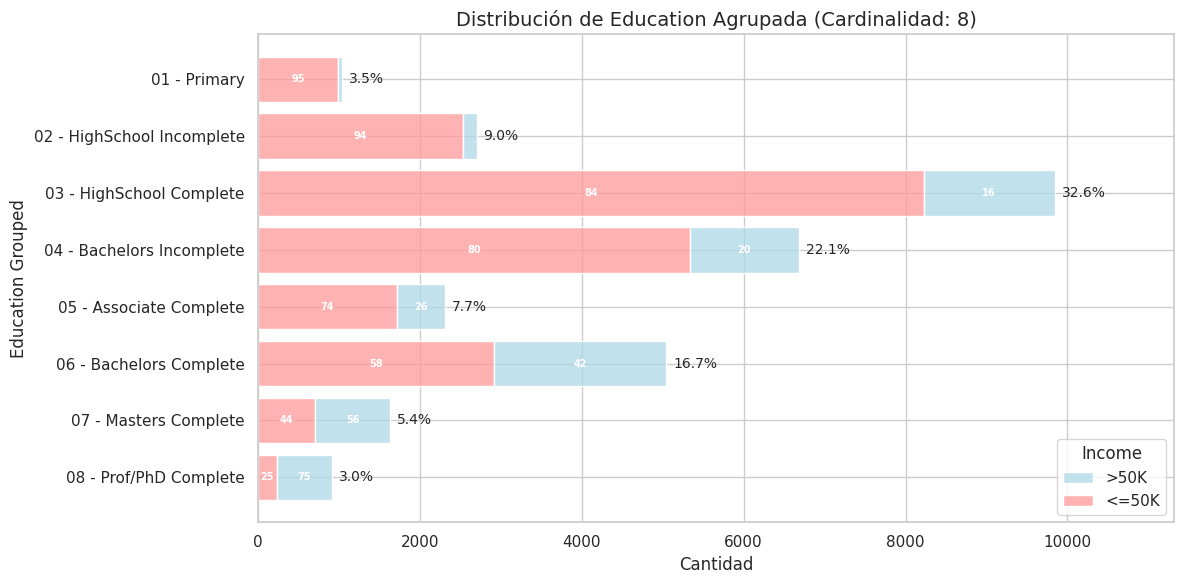

In [15]:
# Ploteamos

cardinalidad_edu_grouped = train['education_grouped'].nunique()
conteo_edu_grouped = train['education_grouped'].value_counts().reindex(new_order)

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico respetando el ordinal
train['education_grouped'] = pd.Categorical(train['education_grouped'], categories=new_order, ordered=True)

sns.histplot(data=train, y='education_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Education Agrupada (Cardinalidad: {cardinalidad_edu_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education Grouped', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_edu_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_edu_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_edu_grouped):
            total_bar = conteo_edu_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['education_grouped'] = train['education_grouped'].astype(object)
plt.tight_layout()
plt.show()

- Reagrupando reducimos la cardinalidada a 8 para usar Ordinal Encoder. Igualmente probaremos con Embeddings con la categorias originales
- ORD_education

### Marital-status
Estado civil del individuo.

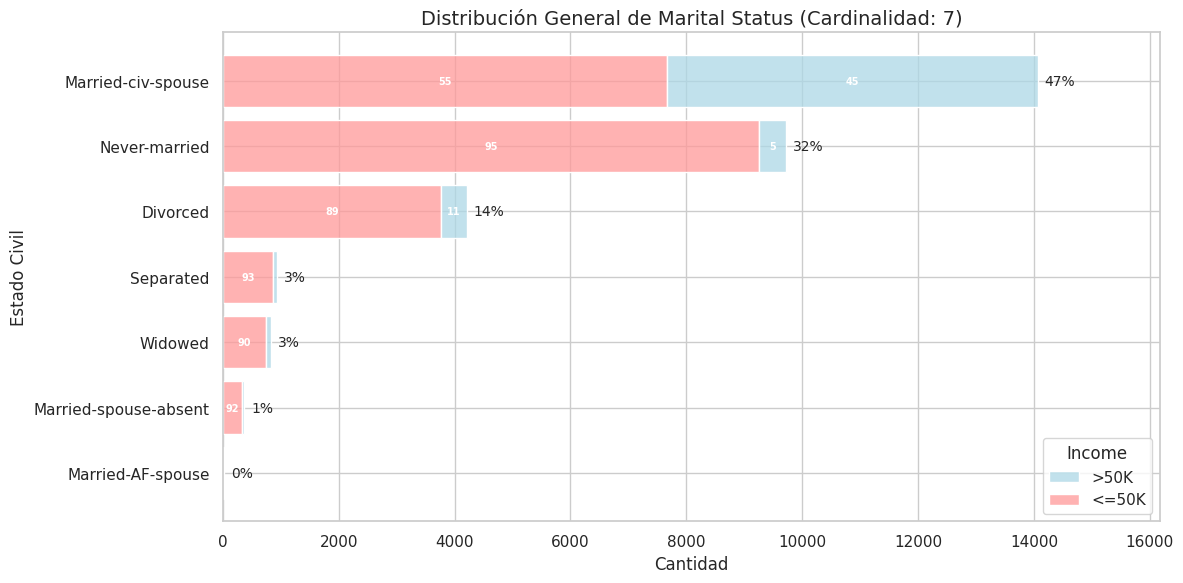

In [16]:
cardinalidad_marital = train['marital-status'].nunique()
conteo_marital = train['marital-status'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['marital-status'] = pd.Categorical(train['marital-status'], categories=conteo_marital.index, ordered=True)

sns.histplot(data=train, y='marital-status', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Marital Status (Cardinalidad: {cardinalidad_marital})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Estado Civil', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_marital.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_marital):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_marital.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['marital-status'] = train['marital-status'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 7 sin orden jerarquico. Usaremos One-Hot Encodding y probaremos con Embeddings luego
- Permite capturar de forma independiente el fuerte impacto que tiene el estado 'Married-civ-spouse' en la variable target (billetera mata galan)
- Que hacemos con Married-AF-spouse???

In [17]:
# 5. Transformación Marital-status -> OHE_marital_status
ohe_marital = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
marital_ohe_train_raw = ohe_marital.fit_transform(train[['marital-status']])
marital_ohe_test_raw = ohe_marital.transform(test[['marital-status']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_marital = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_marital.categories_[0]]
columns_ohe_marital = [f"OHE_MARITAL_STATUS_{cat}" for cat in categories_marital]

# DataFrames
OHE_marital_status_train = pd.DataFrame(marital_ohe_train_raw, columns=columns_ohe_marital, index=train.index)
OHE_marital_status_test = pd.DataFrame(marital_ohe_test_raw, columns=columns_ohe_marital, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_marital_status_train)
variables_transformadas_test.append(OHE_marital_status_test)


- OHE_MARITAL_STATUS_xxx


### Occupation
Tipo de ocupación o área laboral.

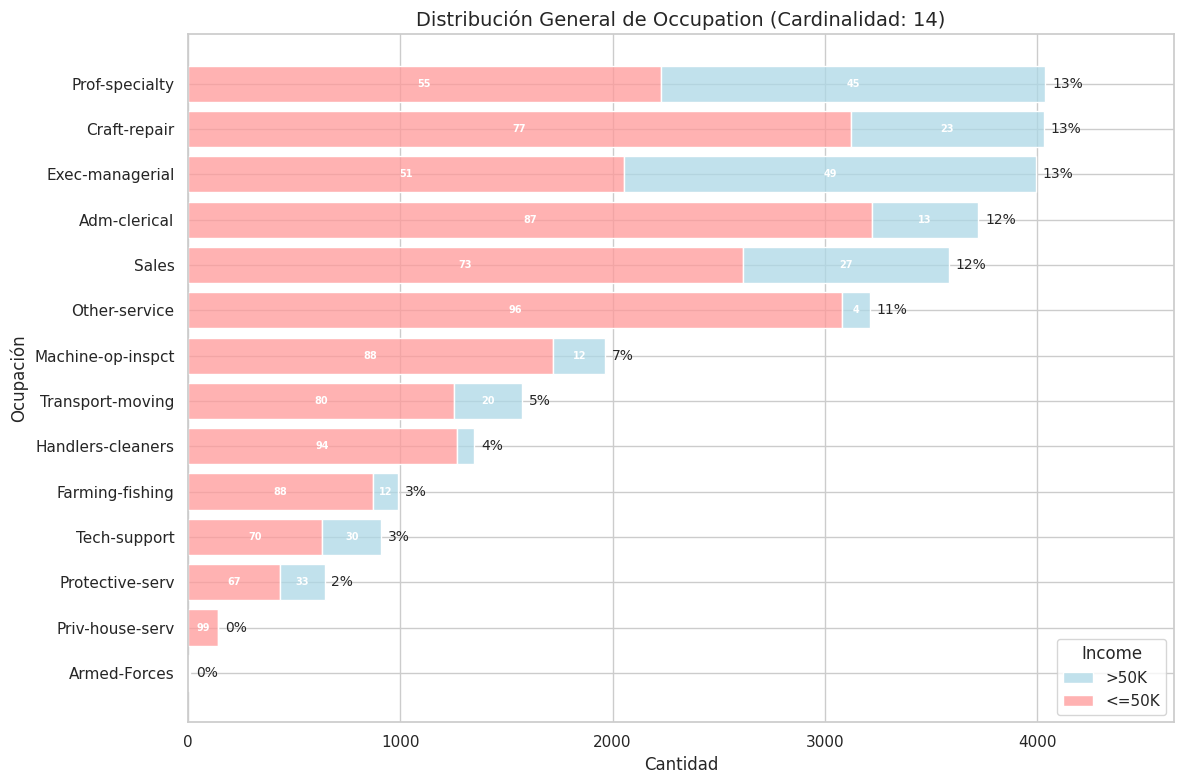

In [18]:
cardinalidad_occupation = train['occupation'].nunique()
conteo_occupation = train['occupation'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
# Ordenamos temporalmente para el gráfico
train['occupation'] = pd.Categorical(train['occupation'], categories=conteo_occupation.index, ordered=True)

sns.histplot(data=train, y='occupation', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Occupation (Cardinalidad: {cardinalidad_occupation})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Ocupación', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_occupation.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_occupation):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_occupation.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['occupation'] = train['occupation'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 14, Embeddings y Freq/Target Encodding. Compararemos resultados

In [19]:
# Implementación de Frequency Encoding para 'occupation'

# 1. Calculamos las frecuencias (proporciones) en el set de entrenamiento
occ_freq_map = train['occupation'].value_counts(normalize=True).to_dict()

# 2. Aplicamos el mapeo a ambos datasets
# Usamos el prefijo 'FRQ_' para identificar la transformación
FRQ_Occupation_train = train['occupation'].map(occ_freq_map)
FRQ_Occupation_test = test['occupation'].map(occ_freq_map)

# Manejo de valores nuevos en test (si los hubiera) con 0
FRQ_Occupation_test = FRQ_Occupation_test.fillna(0)

# Convertimos a Series con nombre para consistencia
FRQ_Occupation_train.name = 'FRQ_Occupation'
FRQ_Occupation_test.name = 'FRQ_Occupation'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(FRQ_Occupation_train)
variables_transformadas_test.append(FRQ_Occupation_test)

print("Mapeo de frecuencias generado y agregado a las listas:")
for occ, freq in list(occ_freq_map.items())[:5]:
    print(f" - {occ}: {freq:.4f}")


Mapeo de frecuencias generado y agregado a las listas:
 - Prof-specialty: 0.1339
 - Craft-repair: 0.1336
 - Exec-managerial: 0.1324
 - Adm-clerical: 0.1234
 - Sales: 0.1188


- Al tener alta cardinalidad, podemos usar alguna transofrmacion matematica como alternativa de los Embeddings como Frequency, Mean o Weight of Evidence
- FRQ_Occupation

In [20]:
# Implementación de Target Encoding para 'occupation'

# 1. Calculamos la media del target (Income > 50K) para cada ocupación en el set de entrenamiento
occ_target_map = BOOL_Income_train.groupby(train['occupation']).mean().to_dict()

# 2. Aplicamos el mapeo a ambos datasets
# Usamos el prefijo 'TAR_' para identificar la transformación
TAR_Occupation_train = train['occupation'].map(occ_target_map)
TAR_Occupation_test = test['occupation'].map(occ_target_map)

# Manejo de valores nuevos en test (si los hubiera) rellenando con la media global de train
global_target_mean = BOOL_Income_train.mean()
TAR_Occupation_test = TAR_Occupation_test.fillna(global_target_mean)

# Convertimos a Series con nombre para consistencia
TAR_Occupation_train.name = 'TAR_Occupation'
TAR_Occupation_test.name = 'TAR_Occupation'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(TAR_Occupation_train)
variables_transformadas_test.append(TAR_Occupation_test)

print("Mapeo de Target Encoding (proporción de >50K) generado y agregado a las listas:")
# Mostramos el top 5 de ocupaciones con mayor proporción de ingresos >50K
for occ, target_mean in sorted(occ_target_map.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f" - {occ}: {target_mean:.4f}")


Mapeo de Target Encoding (proporción de >50K) generado y agregado a las listas:
 - Exec-managerial: 0.4852
 - Prof-specialty: 0.4485
 - Protective-serv: 0.3261
 - Tech-support: 0.3048
 - Sales: 0.2706


- TAR_Occupation

### Relationship


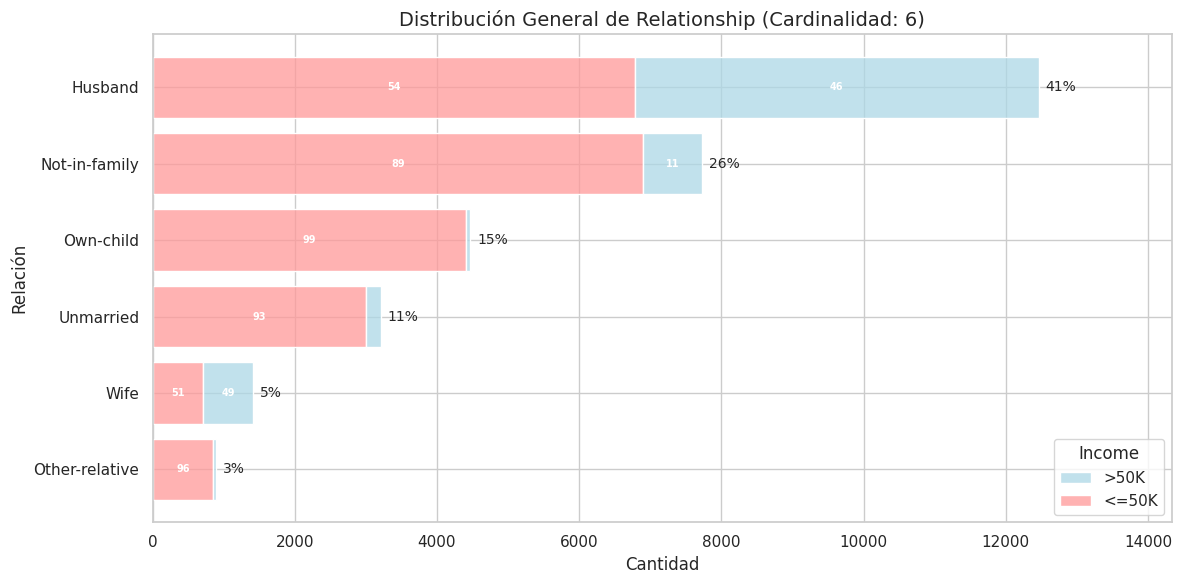

In [21]:
cardinalidad_rel = train['relationship'].nunique()
conteo_rel = train['relationship'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['relationship'] = pd.Categorical(train['relationship'], categories=conteo_rel.index, ordered=True)

sns.histplot(data=train, y='relationship', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Relationship (Cardinalidad: {cardinalidad_rel})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Relación', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_rel.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_rel):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.set_yticks(range(len(conteo_rel)))
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_rel.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['relationship'] = train['relationship'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 6. Utilizaremos One-Hot Encoding ya que son pocas categorías
- Seguramente tenga alta correlacion con Marital_Status

In [22]:
# 1. Transformación Relationship -> OHE_relationship
ohe_rel = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
rel_ohe_train_raw = ohe_rel.fit_transform(train[['relationship']])
rel_ohe_test_raw = ohe_rel.transform(test[['relationship']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_rel = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_rel.categories_[0]]
columns_ohe_rel = [f"OHE_RELATIONSHIP_{cat}" for cat in categories_rel]

# DataFrames
OHE_relationship_train = pd.DataFrame(rel_ohe_train_raw, columns=columns_ohe_rel, index=train.index)
OHE_relationship_test = pd.DataFrame(rel_ohe_test_raw, columns=columns_ohe_rel, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_relationship_train)
variables_transformadas_test.append(OHE_relationship_test)


- OHE_RELATIONSHIP_xxx

### Race
Autoidentificación racial del individuo.

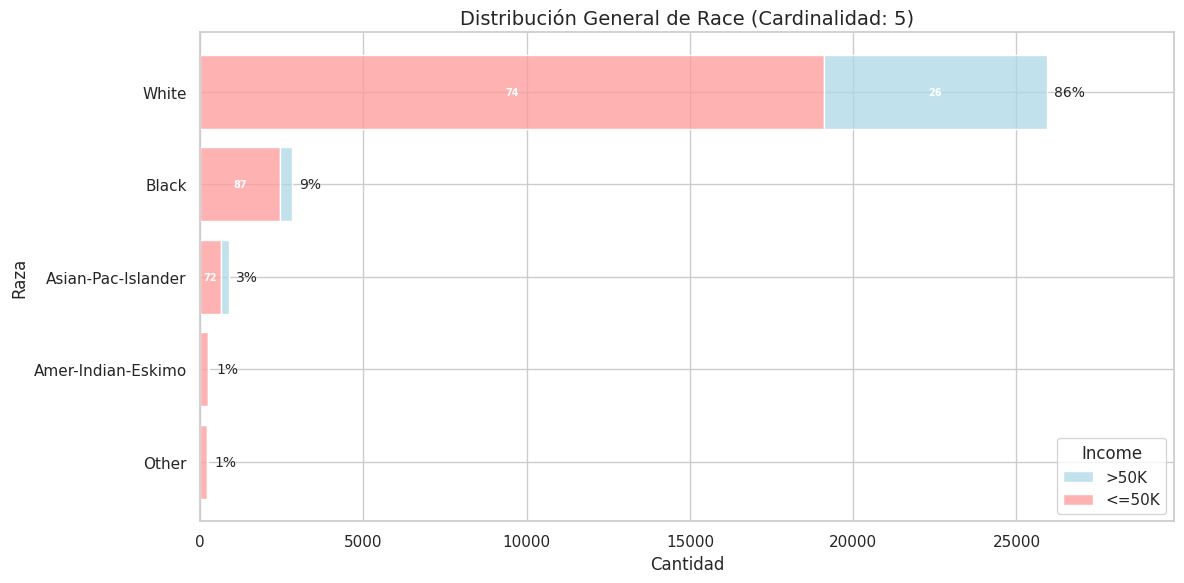

In [23]:
cardinalidad_race = train['race'].nunique()
conteo_race = train['race'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['race'] = pd.Categorical(train['race'], categories=conteo_race.index, ordered=True)

sns.histplot(data=train, y='race', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Race (Cardinalidad: {cardinalidad_race})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race):
            total_bar = conteo_race.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race'] = train['race'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 5
- Ya que son pocos casos que no sean White y Black, agrupamos el resto en Others
- Se ve claramente como los blancos tienen mayores salarios

In [24]:
# 1. Definimos las categorías principales y agrupamos las demás en 'Other'
main_races = ['White', 'Black']

train['race_grouped'] = train['race'].apply(lambda x: x if x in main_races else 'Other')
test['race_grouped'] = test['race'].apply(lambda x: x if x in main_races else 'Other')

# 2. Aplicamos One-Hot Encoding a las categorías agrupadas
ohe_race = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

race_ohe_train_raw = ohe_race.fit_transform(train[['race_grouped']])
race_ohe_test_raw = ohe_race.transform(test[['race_grouped']])

# Nombres de columnas limpios (prefijo en mayúsculas)
columns_ohe_race = [f"OHE_RACE_{cat.replace(' ', '_').replace('-', '_')}" for cat in ohe_race.categories_[0]]

# Crear DataFrames
OHE_race_train = pd.DataFrame(race_ohe_train_raw, columns=columns_ohe_race, index=train.index)
OHE_race_test = pd.DataFrame(race_ohe_test_raw, columns=columns_ohe_race, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_race_train)
variables_transformadas_test.append(OHE_race_test)


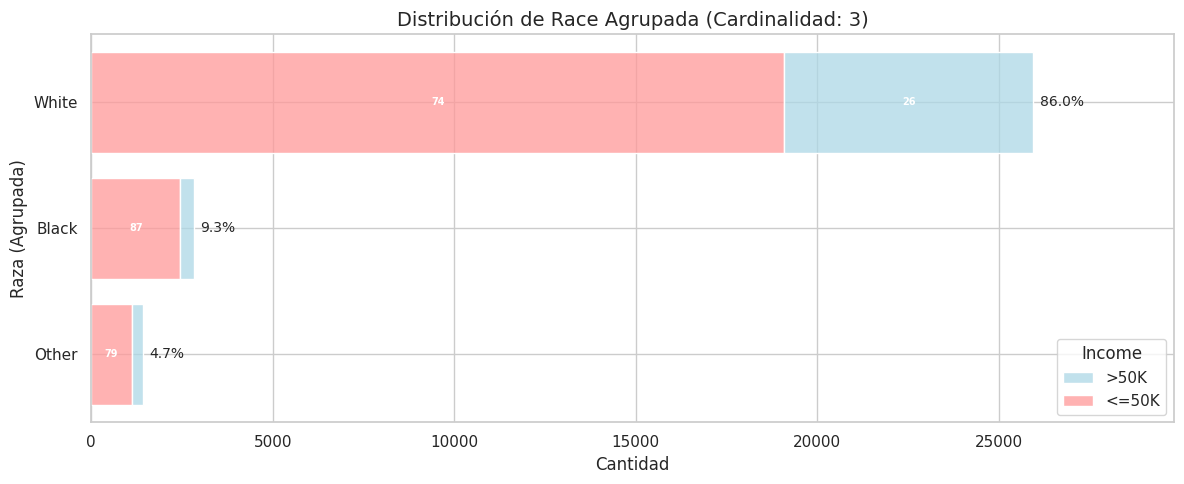

In [25]:
# --- Visualización ---
cardinalidad_race_grouped = train['race_grouped'].nunique()
conteo_race_grouped = train['race_grouped'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['race_grouped'] = pd.Categorical(train['race_grouped'], categories=conteo_race_grouped.index, ordered=True)

sns.histplot(data=train, y='race_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Race Agrupada (Cardinalidad: {cardinalidad_race_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza (Agrupada)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race_grouped):
            total_bar = conteo_race_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race_grouped'] = train['race_grouped'].astype(object)
plt.tight_layout()
plt.show()


- OHE_RACE

### Sex
Sexo biológico del individuo (masculino o femenino).

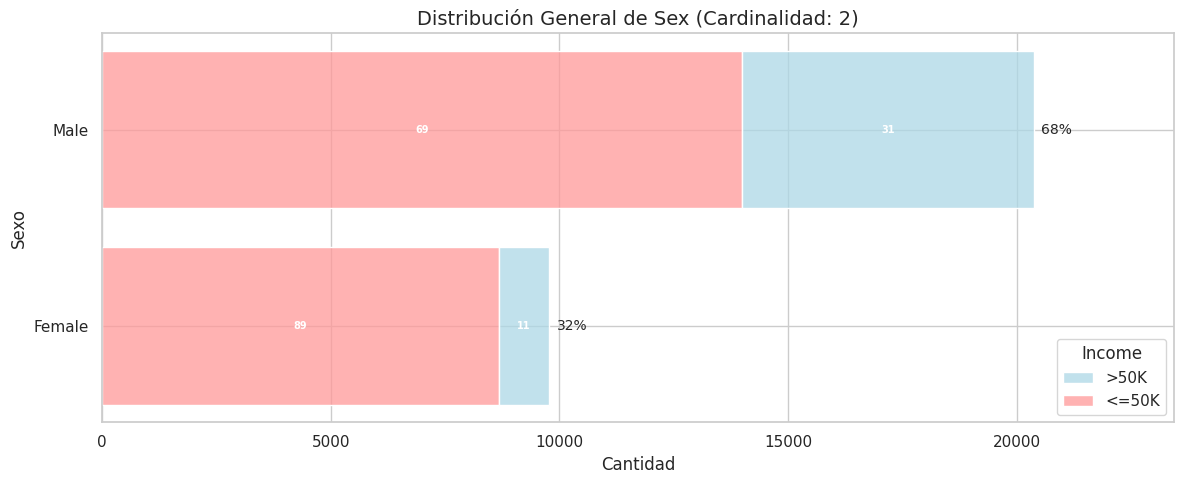

In [26]:
cardinalidad_sex = train['sex'].nunique()
conteo_sex = train['sex'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['sex'] = pd.Categorical(train['sex'], categories=conteo_sex.index, ordered=True)

sns.histplot(data=train, y='sex', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Sex (Cardinalidad: {cardinalidad_sex})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Sexo', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_sex.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_sex):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))  # Corregido: se asegura de que idx sea entero
        if idx < len(conteo_sex):
            total_bar = conteo_sex.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['sex'] = train['sex'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 2 (Binaria)
- 2/3 de la base son hombres
- La proporcionde hombres con salarios altos es casi del triple que de mujeres

In [27]:
# 8. Transformación Sex -> BOOL_is_men
sex_mapping = {'Male': 1, 'Female': 0}

BOOL_is_men_train = train['sex'].map(sex_mapping).astype(int)
BOOL_is_men_test = test['sex'].map(sex_mapping).astype(int)

# Asignamos nombre para consistencia
BOOL_is_men_train.name = 'BOOL_is_men'
BOOL_is_men_test.name = 'BOOL_is_men'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_is_men_train)
variables_transformadas_test.append(BOOL_is_men_test)


- BOOL_is_men

### Skill-profile
Habilidad principal o conocimiento técnico adquirido que podría aplicar en el trabajo.

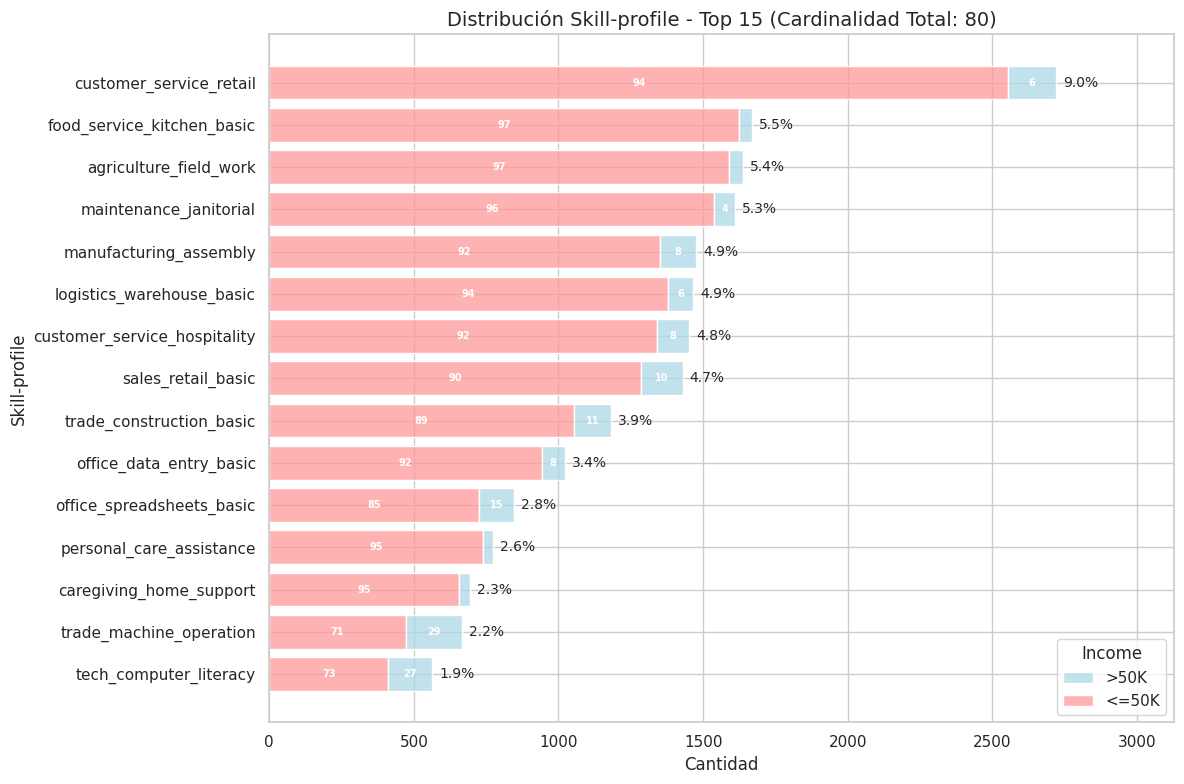

In [28]:
cardinalidad_skill = train['skill-profile'].nunique()
conteo_skill = train['skill-profile'].value_counts()
top_15_skills = conteo_skill.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top = train[train['skill-profile'].isin(top_15_skills.index)].copy()
train_top['skill-profile'] = pd.Categorical(train_top['skill-profile'], categories=top_15_skills.index, ordered=True)

sns.histplot(data=train_top, y='skill-profile', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Skill-profile - Top 15 (Cardinalidad Total: {cardinalidad_skill})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Skill-profile', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_skills.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_skills):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_skills):
            total_bar = top_15_skills.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 80, Embeddings
- Para el primer modelo podriamos probar con Freq/Target/WoE

In [29]:
# 10. Transformación Skill-profile -> FRQ_skill_profile
# Cardinalidad 80: Utilizamos Frequency Encoding

# 1. Calculamos las frecuencias en entrenamiento
skill_freq_map = train['skill-profile'].value_counts(normalize=True).to_dict()

# 2. Mapeamos a ambos datasets
FRQ_skill_profile_train = train['skill-profile'].map(skill_freq_map)
FRQ_skill_profile_test = test['skill-profile'].map(skill_freq_map)

# Manejo de nulos en test (categorías que no estaban en train) con 0
FRQ_skill_profile_test = FRQ_skill_profile_test.fillna(0)

# Convertimos a Series con nombre
FRQ_skill_profile_train.name = 'FRQ_skill_profile'
FRQ_skill_profile_test.name = 'FRQ_skill_profile'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(FRQ_skill_profile_train)
variables_transformadas_test.append(FRQ_skill_profile_test)

print(f"Frequency Encoding aplicado a 'skill-profile' y agregado a las listas.")
print(f"Ejemplo de mapeo (Top 5 habilidades):")
for skill, freq in list(skill_freq_map.items())[:5]:
    print(f" - {skill}: {freq:.4f}")


Frequency Encoding aplicado a 'skill-profile' y agregado a las listas.
Ejemplo de mapeo (Top 5 habilidades):
 - customer_service_retail: 0.0902
 - food_service_kitchen_basic: 0.0553
 - agriculture_field_work: 0.0543
 - maintenance_janitorial: 0.0534
 - manufacturing_assembly: 0.0489


- FRQ_skill_profile

In [30]:
# Implementación de Target Encoding para 'skill-profile'

# 1. Calculamos la media del target (Income > 50K) para cada skill en el set de entrenamiento
skill_target_map = BOOL_Income_train.groupby(train['skill-profile']).mean().to_dict()

# 2. Aplicamos el mapeo a ambos datasets
TAR_skill_profile_train = train['skill-profile'].map(skill_target_map)
TAR_skill_profile_test = test['skill-profile'].map(skill_target_map)

# Manejo de valores nuevos en test rellenando con la media global de train
global_target_mean = BOOL_Income_train.mean()
TAR_skill_profile_test = TAR_skill_profile_test.fillna(global_target_mean)

# Convertimos a Series con nombre para consistencia
TAR_skill_profile_train.name = 'TAR_skill_profile'
TAR_skill_profile_test.name = 'TAR_skill_profile'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(TAR_skill_profile_train)
variables_transformadas_test.append(TAR_skill_profile_test)

print("Mapeo de Target Encoding (TAR_skill_profile) generado y agregado a las listas:")
# Mostramos el top 5 de habilidades con mayor proporción de ingresos >50K
for skill, target_mean in sorted(skill_target_map.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f" - {skill}: {target_mean:.4f}")


Mapeo de Target Encoding (TAR_skill_profile) generado y agregado a las listas:
 - executive_decision_support: 0.9730
 - management_strategic_planning: 0.9322
 - tech_cloud_systems: 0.9214
 - finance_investment_analysis: 0.9200
 - management_operations: 0.9048


- TAR_skill_profile

### Native-country
País de nacimiento del individuo.

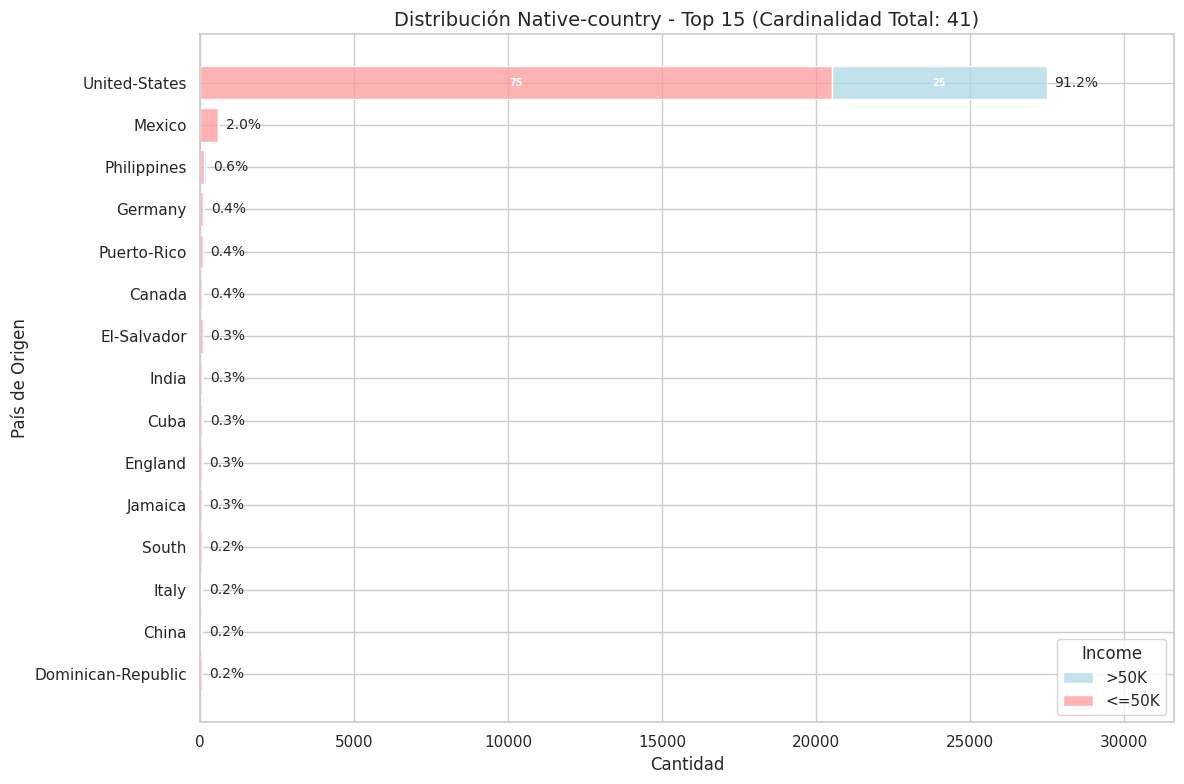

In [31]:
cardinalidad_country = train['native-country'].nunique()
conteo_country = train['native-country'].value_counts()
top_15_countries = conteo_country.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top_c = train[train['native-country'].isin(top_15_countries.index)].copy()
train_top_c['native-country'] = pd.Categorical(train_top_c['native-country'], categories=top_15_countries.index, ordered=True)

sns.histplot(data=train_top_c, y='native-country', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Native-country - Top 15 (Cardinalidad Total: {cardinalidad_country})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_countries.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_countries):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_countries):
            total_bar = top_15_countries.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 41, pero pocos registors con valores distintos de US y MEX. Reagrupamos y One-Hot

In [32]:
# Agrupamos en United-States, Mexico y Other, luego aplicamos One-Hot Encoding

main_countries = ['United-States', 'Mexico']

train['country_grouped'] = train['native-country'].str.strip().apply(lambda x: x if x in main_countries else 'Other')
test['country_grouped'] = test['native-country'].str.strip().apply(lambda x: x if x in main_countries else 'Other')

ohe_country = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
country_ohe_train_raw = ohe_country.fit_transform(train[['country_grouped']])
country_ohe_test_raw = ohe_country.transform(test[['country_grouped']])

columns_ohe_country = [f"OHE_COUNTRY_{cat.replace('-', '_')}" for cat in ohe_country.categories_[0]]

OHE_country_train = pd.DataFrame(country_ohe_train_raw, columns=columns_ohe_country, index=train.index)
OHE_country_test = pd.DataFrame(country_ohe_test_raw, columns=columns_ohe_country, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_country_train)
variables_transformadas_test.append(OHE_country_test)


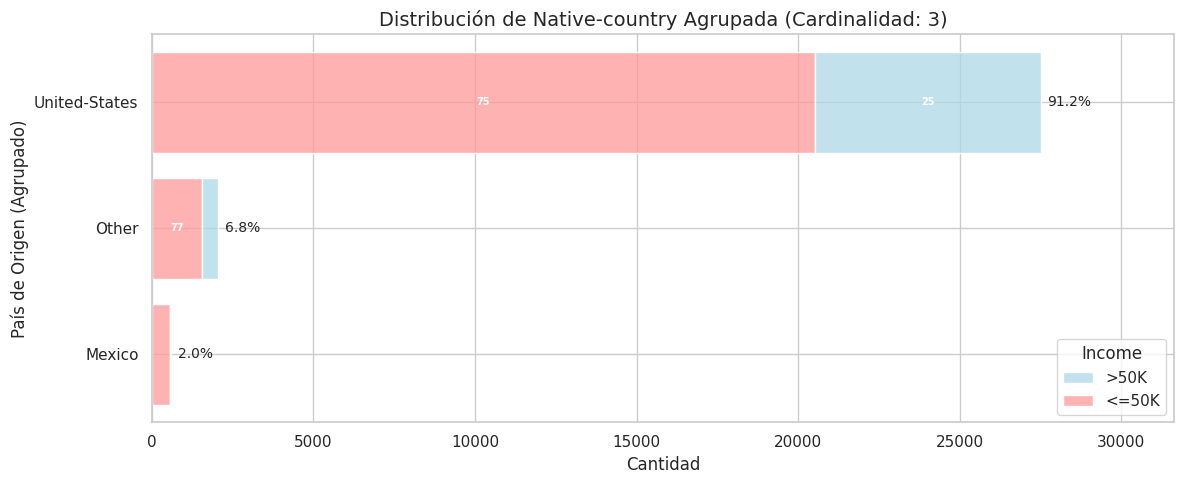

In [33]:
# --- Visualización ---
cardinalidad_country_grouped = train['country_grouped'].nunique()
conteo_country_grouped = train['country_grouped'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['country_grouped'] = pd.Categorical(train['country_grouped'], categories=conteo_country_grouped.index, ordered=True)

sns.histplot(data=train, y='country_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Native-country Agrupada (Cardinalidad: {cardinalidad_country_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen (Agrupado)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_country_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_country_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_country_grouped):
            total_bar = conteo_country_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['country_grouped'] = train['country_grouped'].astype(object)
plt.tight_layout()
plt.show()

- OHE_COUNTRY_xxx

### Hours-per-week
Cantidad de horas trabajadas por semana (variable numérica).

Estadísticas descriptivas de la variable 'hours-per-week':


,hours-per-week
count,30162.000000
mean,40.931238
std,11.979984
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


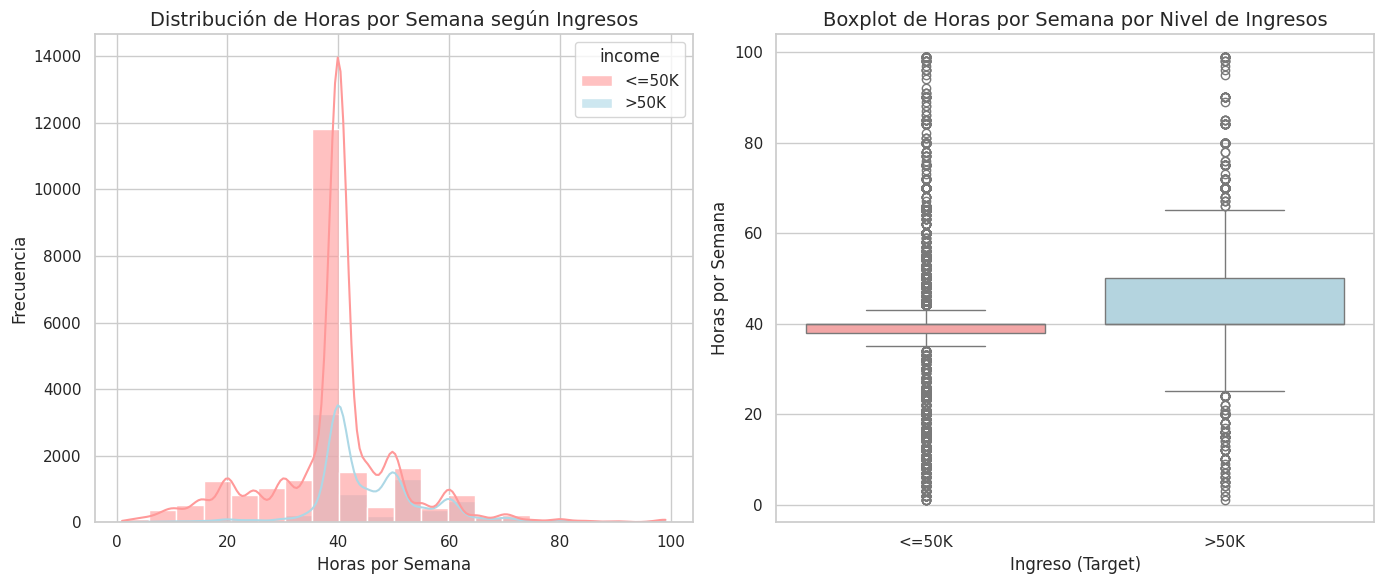

In [34]:
# Mostrar estadísticas descriptivas de la variable 'hours-per-week'
print("Estadísticas descriptivas de la variable 'hours-per-week':")
display(train['hours-per-week'].describe())

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='hours-per-week', hue='income', bins=20, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Horas por Semana según Ingresos', fontsize=14)
axes[0].set_xlabel('Horas por Semana', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Horas por Semana por clase (Income)
sns.boxplot(data=train, x='income', y='hours-per-week', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Horas por Semana por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Horas por Semana', fontsize=12)

plt.tight_layout()
plt.show()

- Variable continua de baja dispersion
- La distribucion se centra en 40hs (la gente que trabja full time)
- La binerizamos y trabajamos como Ordinal, o la capeamos y trabajamos como continua

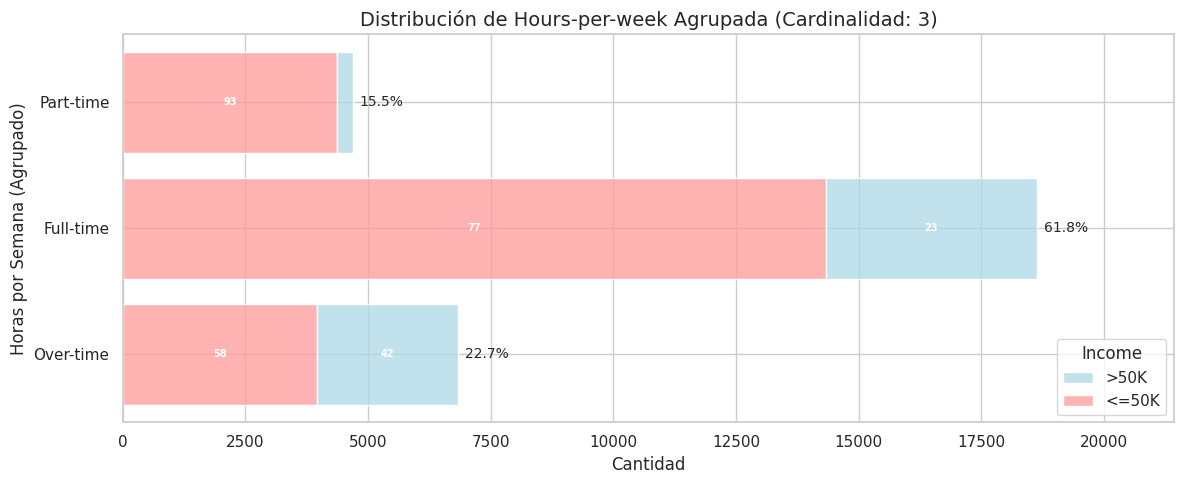

In [35]:
# 9. Transformación Hours-per-week -> Binning manual

# Definimos los rangos: Part-time (<35), Full-time (35-45), Over-time (>45)
def bin_hours(h):
    if h < 35:
        return 'Part-time'
    elif 35 <= h <= 45:
        return 'Full-time'

    else:
        return 'Over-time'

train['hours_binned'] = train['hours-per-week'].apply(bin_hours)
test['hours_binned'] = test['hours-per-week'].apply(bin_hours)

# --- Visualización ---
cardinalidad_hours_binned = train['hours_binned'].nunique()
order_hours = ['Part-time', 'Full-time', 'Over-time']
conteo_hours_binned = train['hours_binned'].value_counts().reindex(order_hours)

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['hours_binned'] = pd.Categorical(train['hours_binned'], categories=order_hours, ordered=True)

sns.histplot(data=train, y='hours_binned', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Hours-per-week Agrupada (Cardinalidad: {cardinalidad_hours_binned})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Horas por Semana (Agrupado)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_hours_binned.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_hours_binned):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_hours_binned):
            total_bar = conteo_hours_binned.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['hours_binned'] = train['hours_binned'].astype(object)
plt.tight_layout()
plt.show()


- Como era de esperar, se verificacomo la gente que trabaja mas horas tiene mejores salarios a nivel nominal

In [36]:
# Aplicamos Ordinal Encoding manteniendo el orden lógico

# Definimos el orden explícito: Part-time (0) < Full-time (1) < Over-time (2)
hours_categories = [['Part-time', 'Full-time', 'Over-time']]
encoder_hours = OrdinalEncoder(categories=hours_categories)

ORD_hours_train = pd.Series(
    encoder_hours.fit_transform(train[['hours_binned']]).flatten(),
    index=train.index,
    name='ORD_hours_per_week'
)

ORD_hours_test = pd.Series(
    encoder_hours.transform(test[['hours_binned']]).flatten(),
    index=test.index,
    name='ORD_hours_per_week'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(ORD_hours_train)
variables_transformadas_test.append(ORD_hours_test)


- ORD_hours_per_week

In [37]:
# Transformación alterna para Hours-per-week -> OHE_hours
ohe_hours = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

hours_ohe_train_raw = ohe_hours.fit_transform(train[['hours_binned']])
hours_ohe_test_raw = ohe_hours.transform(test[['hours_binned']])

columns_ohe_hours = [f"OHE_HOURS_PER_WEEK_{cat.replace('-', '_')}" for cat in ohe_hours.categories_[0]]

OHE_hours_train = pd.DataFrame(hours_ohe_train_raw, columns=columns_ohe_hours, index=train.index)
OHE_hours_test = pd.DataFrame(hours_ohe_test_raw, columns=columns_ohe_hours, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_hours_train)
variables_transformadas_test.append(OHE_hours_test)


- OHE_HOURS_PER_WEEK_xxx

### Capital-gain
Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

,capital-gain
count,30162.000000
mean,1092.007858
std,7406.346497
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000



Cantidad de registros con capital-gain igual a 0: 27624
Porcentaje de registros con capital-gain igual a 0: 91.59%



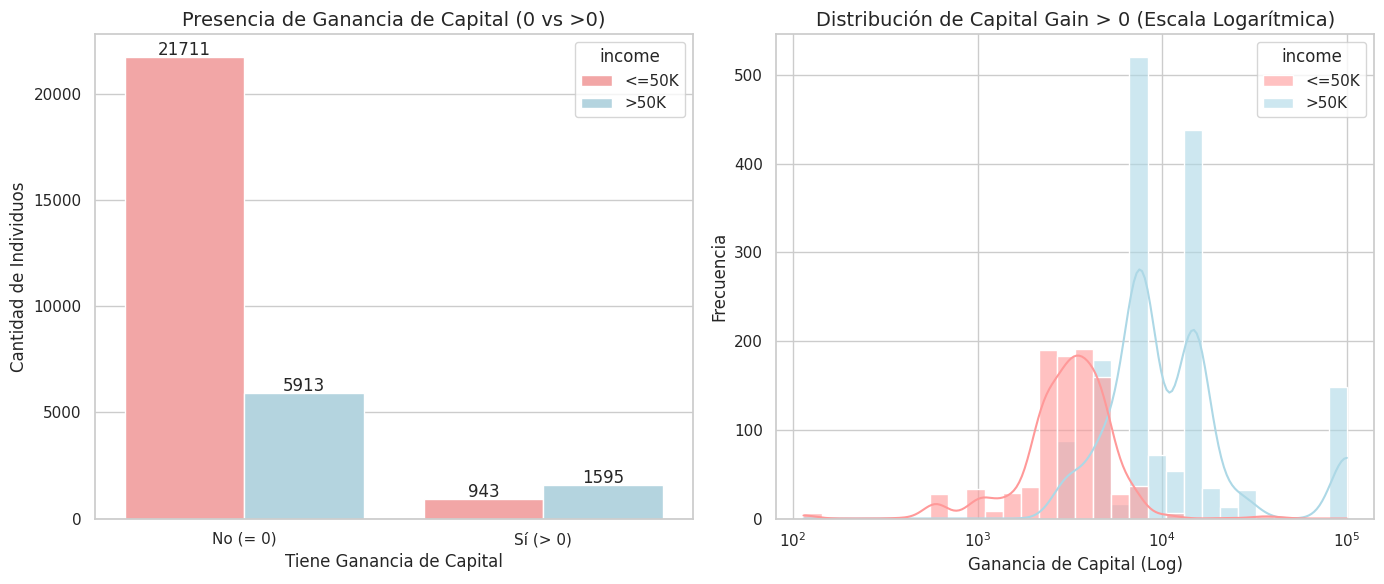

In [38]:
display(train['capital-gain'].describe())

zeros_count = (train['capital-gain'] == 0).sum()
total_count = len(train)
zeros_pct = (zeros_count / total_count) * 100

print(f"\nCantidad de registros con capital-gain igual a 0: {zeros_count}")
print(f"Porcentaje de registros con capital-gain igual a 0: {zeros_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_gain'] = train['capital-gain'] > 0

# 1. Countplot de Ceros vs No Ceros
sns.countplot(data=train, x='has_capital_gain', hue='income', ax=axes[0], palette=custom_palette)
axes[0].set_title('Presencia de Ganancia de Capital (0 vs >0)', fontsize=14)
axes[0].set_xlabel('Tiene Ganancia de Capital', fontsize=12)
axes[0].set_ylabel('Cantidad de Individuos', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (= 0)', 'Sí (> 0)'])

# Agregar valores exactos sobre las barras del countplot
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Distribución de las ganancias > 0 (Escala Logarítmica)
non_zero_gains = train[train['capital-gain'] > 0]
sns.histplot(data=non_zero_gains, x='capital-gain', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6, log_scale=True)
axes[1].set_title('Distribución de Capital Gain > 0 (Escala Logarítmica)', fontsize=14)
axes[1].set_xlabel('Ganancia de Capital (Log)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_gain'])

- Variable Continua
- 92% de los registros tienen valor de 0
- Para los que reportan algo de Capital Gain, la proporcion de registros con Ingresos altos se considerablemente mayor contra los que no reportan
- Distribucion muy sezgada hacia la derecha, aplicamos Log Transform y luego Escalamos

In [39]:
# 1. Crear indicador binario con el nombre solicitado
BOOL_has_capital_gain_train = (train['capital-gain'] > 0).astype(int)
BOOL_has_capital_gain_test = (test['capital-gain'] > 0).astype(int)

BOOL_has_capital_gain_train.name = 'BOOL_has_capital_gain'
BOOL_has_capital_gain_test.name = 'BOOL_has_capital_gain'

# 2. Transformación Logarítmica para manejar el sesgo extremo
log_gain_train = np.log1p(train[['capital-gain']])
log_gain_test = np.log1p(test[['capital-gain']])

# 3. Escalado de la magnitud logarítmica para la red neuronal
scaler_gain = MinMaxScaler()

LOG_capital_gain_train = pd.Series(
    scaler_gain.fit_transform(log_gain_train).flatten(),
    index=train.index,
    name='LOG_capital_gain'
)

LOG_capital_gain_test = pd.Series(
    scaler_gain.transform(log_gain_test).flatten(),
    index=test.index,
    name='LOG_capital_gain'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_has_capital_gain_train)
variables_transformadas_test.append(BOOL_has_capital_gain_test)

variables_transformadas_train.append(LOG_capital_gain_train)
variables_transformadas_test.append(LOG_capital_gain_test)

display(LOG_capital_gain_train.describe())


,LOG_capital_gain
count,30162.000000
mean,0.064592
std,0.214586
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


- Creamos BOOL_has_capital_gain como Booleana, para que ayude en el entrenamiento del modelo
- Creamos LOG_capital_gain que seria la variable orignal transofmrada dos veces

### Capital-loss
Pérdidas declaradas por capital.


Cantidad de registros con capital-loss igual a 0: 28735
Porcentaje de registros con capital-loss igual a 0: 95.27%



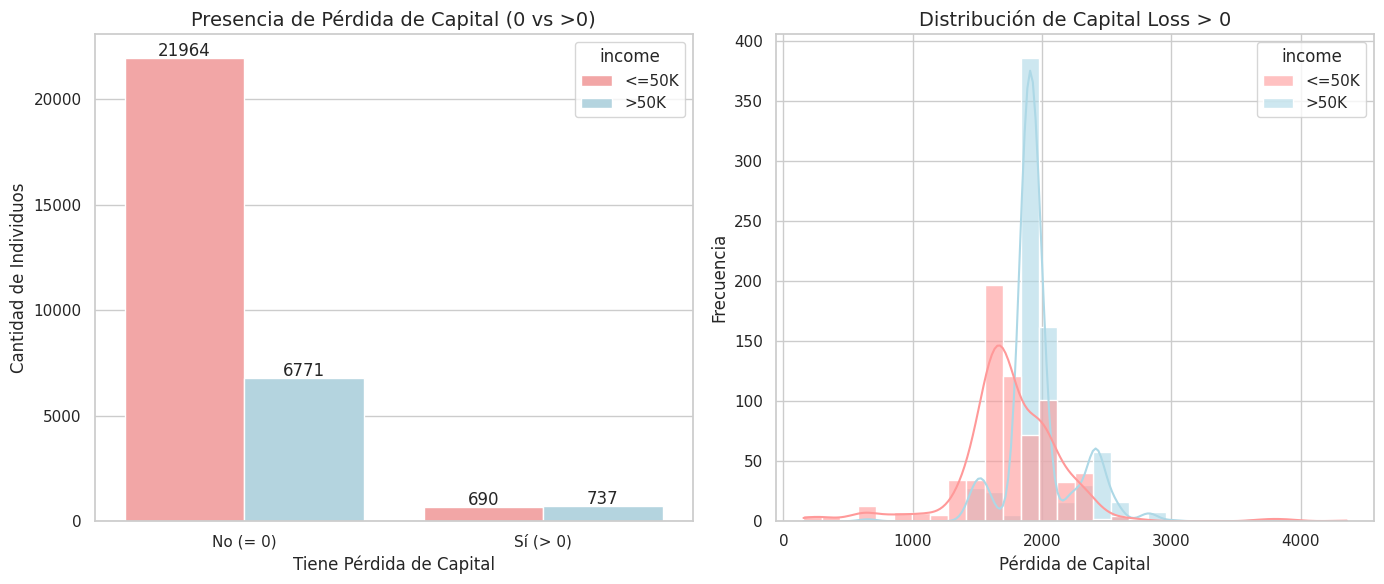

In [40]:
zeros_loss_count = (train['capital-loss'] == 0).sum()
total_count = len(train)
zeros_loss_pct = (zeros_loss_count / total_count) * 100

print(f"\nCantidad de registros con capital-loss igual a 0: {zeros_loss_count}")
print(f"Porcentaje de registros con capital-loss igual a 0: {zeros_loss_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_loss'] = train['capital-loss'] > 0

# 1. Countplot de Ceros vs No Ceros
sns.countplot(data=train, x='has_capital_loss', hue='income', ax=axes[0], palette=custom_palette)
axes[0].set_title('Presencia de Pérdida de Capital (0 vs >0)', fontsize=14)
axes[0].set_xlabel('Tiene Pérdida de Capital', fontsize=12)
axes[0].set_ylabel('Cantidad de Individuos', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (= 0)', 'Sí (> 0)'])

# Agregar valores exactos sobre las barras del countplot
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Distribución de las pérdidas > 0 (Magnitud Original)
non_zero_losses = train[train['capital-loss'] > 0]
sns.histplot(data=non_zero_losses, x='capital-loss', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6)
axes[1].set_title('Distribución de Capital Loss > 0', fontsize=14)
axes[1].set_xlabel('Pérdida de Capital', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_loss'])


- Tambien Continua, con 95% de registros en 0
- Aqui las proporciones de los que tienen Ingresos altos e Ingresos bajos es casi igual, a diferencia como pasaba en Captial-Gain
- Tambien con mucho sezgo hacia la cola derecha, aplicamos Log Transform y leugo MinMax Scaler

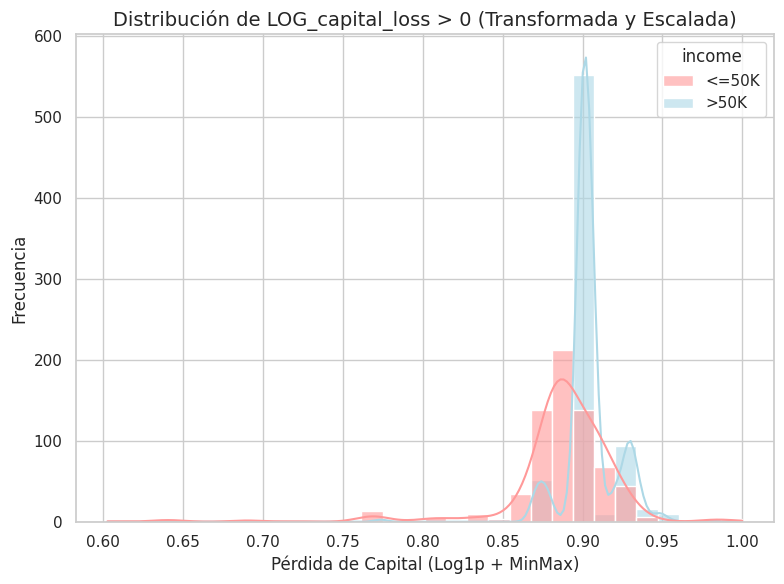

In [41]:
# 1. Crear indicador binario para pérdidas
BOOL_has_capital_loss_train = (train['capital-loss'] > 0).astype(int)
BOOL_has_capital_loss_test = (test['capital-loss'] > 0).astype(int)

BOOL_has_capital_loss_train.name = 'BOOL_has_capital_loss'
BOOL_has_capital_loss_test.name = 'BOOL_has_capital_loss'

# 2. Transformación Logarítmica para manejar el sesgo extremo
log_loss_train = np.log1p(train[['capital-loss']])
log_loss_test = np.log1p(test[['capital-loss']])

# 3. Escalado MinMax de la magnitud logarítmica
scaler_loss = MinMaxScaler()

LOG_capital_loss_train = pd.Series(
    scaler_loss.fit_transform(log_loss_train).flatten(),
    index=train.index,
    name='LOG_capital_loss'
)

LOG_capital_loss_test = pd.Series(
    scaler_loss.transform(log_loss_test).flatten(),
    index=test.index,
    name='LOG_capital_loss'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_has_capital_loss_train)
variables_transformadas_test.append(BOOL_has_capital_loss_test)

variables_transformadas_train.append(LOG_capital_loss_train)
variables_transformadas_test.append(LOG_capital_loss_test)

# 4. Visualización de la variable transformada
temp_df = pd.DataFrame({
    'LOG_capital_loss': LOG_capital_loss_train,
    'income': train['income']
})

# Filtramos los ceros para ver la distribución de los valores reales transformados
transformed_non_zero = temp_df[temp_df['LOG_capital_loss'] > 0]

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(data=transformed_non_zero, x='LOG_capital_loss', hue='income', bins=30, kde=True, palette=custom_palette, alpha=0.6, ax=ax)
ax.set_title('Distribución de LOG_capital_loss > 0 (Transformada y Escalada)', fontsize=14)
ax.set_xlabel('Pérdida de Capital (Log1p + MinMax)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()


- Analogo a como hicimos con Capital Gain, creamos BOOL_has_capital_loss como Booleana, para que ayude en el entrenamiento del modelo
- Creamos LOG_capital_loss que seria la variable orignal transofmrada dos veces

### Consolidación Final de Variables


In [42]:
# Creación de los DataFrames finales X_train y X_test concatenando las listas de consolidación
X_train = pd.concat(variables_transformadas_train, axis=1)
X_test = pd.concat(variables_transformadas_test, axis=1)

# Asignación de la variable objetivo
y_train = BOOL_Income_train
y_test = BOOL_Income_test

# Verificación de dimensiones y visualización
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Total de features: {X_train.shape[1]}")
display(X_train.head())


Dimensiones de X_train: (30162, 41)
Dimensiones de X_test: (15060, 41)
Total de features: 41


,SCA_age,OHE_WORKCLASS_Federal-gov,OHE_WORKCLASS_Local-gov,OHE_WORKCLASS_Private,OHE_WORKCLASS_Self-emp-inc,OHE_WORKCLASS_Self-emp-not-inc,OHE_WORKCLASS_State-gov,OHE_WORKCLASS_Without-pay,ORD_education,OHE_MARITAL_STATUS_Divorced,OHE_MARITAL_STATUS_Married_AF_spouse,OHE_MARITAL_STATUS_Married_civ_spouse,OHE_MARITAL_STATUS_Married_spouse_absent,OHE_MARITAL_STATUS_Never_married,OHE_MARITAL_STATUS_Separated,OHE_MARITAL_STATUS_Widowed,FRQ_Occupation,TAR_Occupation,OHE_RELATIONSHIP_Husband,OHE_RELATIONSHIP_Not_in_family,OHE_RELATIONSHIP_Other_relative,OHE_RELATIONSHIP_Own_child,OHE_RELATIONSHIP_Unmarried,OHE_RELATIONSHIP_Wife,OHE_RACE_Black,OHE_RACE_Other,OHE_RACE_White,BOOL_is_men,FRQ_skill_profile,TAR_skill_profile,OHE_COUNTRY_Mexico,OHE_COUNTRY_Other,OHE_COUNTRY_United_States,ORD_hours_per_week,OHE_HOURS_PER_WEEK_Full_time,OHE_HOURS_PER_WEEK_Over_time,OHE_HOURS_PER_WEEK_Part_time,BOOL_has_capital_gain,LOG_capital_gain,BOOL_has_capital_loss,LOG_capital_loss
0,0.400000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.123367,0.133835,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.048936,0.084688,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1,0.667492,0,0.0
1,0.600000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.132352,0.485220,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.009548,0.614583,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0.000000,0,0.0
2,0.381818,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044758,0.061481,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.054307,0.028694,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0.000000,0,0.0
3,0.654545,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.044758,0.061481,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0.033851,0.077375,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0.000000,0,0.0
4,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.133877,0.448489,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0.005338,0.881988,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0,0.000000,0,0.0


### Logistic Regression (Baseline)

Iniciando búsqueda de hiperparámetros con Random Search...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Mejores hiperparámetros encontrados:
{'solver': 'saga', 'penalty': 'l1', 'class_weight': None, 'C': np.float64(29.763514416313132)}
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     11360
           1       0.83      0.72      0.77      3700

    accuracy                           0.89     15060
   macro avg       0.87      0.83      0.85     15060
weighted avg       0.89      0.89      0.89     15060



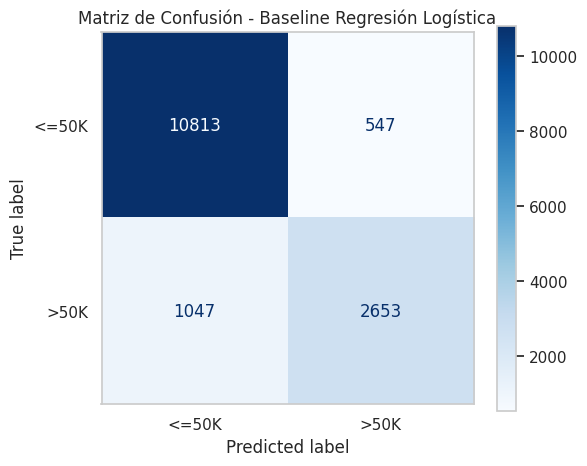

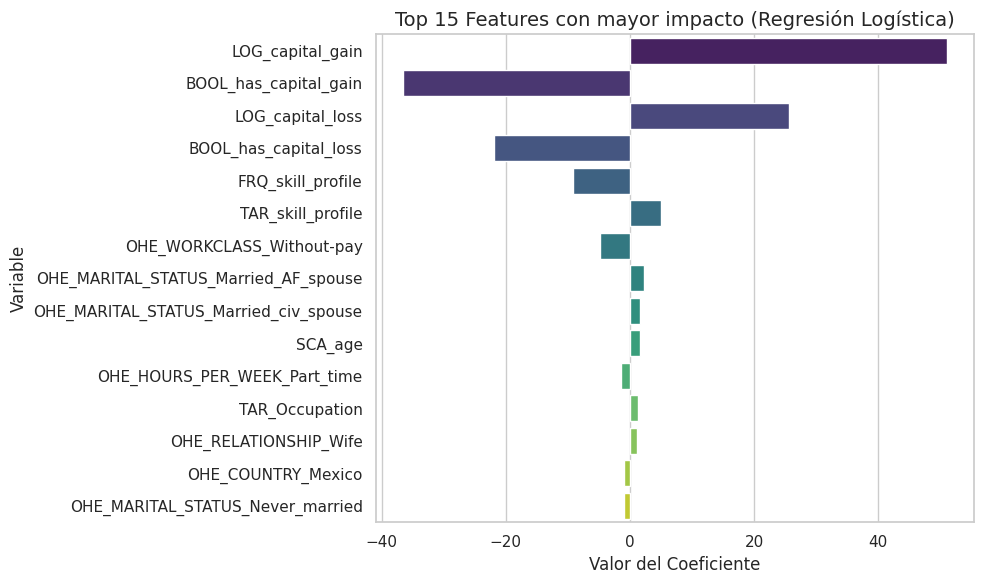

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Definir el modelo base
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# 2. Definir el espacio de búsqueda de hiperparámetros
# Agregamos 'class_weight' para que pruebe balancear las clases automáticamente
param_distributions = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'], # Estos solvers soportan tanto l1 como l2
    'class_weight': [None, 'balanced']
}

# 3. Configurar RandomizedSearchCV
# Optimizamos 'f1_macro' como métrica principal, con 5 folds de Cross-Validation
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_distributions,
    n_iter=15,          # Número de combinaciones aleatorias a probar
    scoring='f1_macro', # Métrica objetivo a optimizar
    cv=5,               # Cantidad de folds
    random_state=42,
    n_jobs=-1,          # Usar todos los procesadores disponibles
    verbose=1
)

# 4. Entrenar (Búsqueda de hiperparámetros)
print("Iniciando búsqueda de hiperparámetros con Random Search...")
random_search.fit(X_train, y_train)

# Resultados de la búsqueda
print("\nMejores hiperparámetros encontrados:")
print(random_search.best_params_)

# 5. Evaluación en el conjunto de prueba (Test)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)


print("Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Graficar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Baseline Regresión Logística')
plt.grid(False)
plt.show()

# 7. Importancia de las variables (Coeficientes absolutos)
coefs = best_model.coef_[0]
features = X_train.columns
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis', ax=ax, hue='Feature', legend=False)
ax.set_title('Top 15 Features con mayor impacto (Regresión Logística)', fontsize=14)
ax.set_xlabel('Valor del Coeficiente', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()


- Accuracy: .89
- F1 Macro: .85

### AutoML (LightGBM)

Iniciando entrenamiento con AutoML...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



--- RESULTADOS DEL MEJOR MODELO ---
Mejor algoritmo: lgbm
Mejores hiperparámetros: {'n_estimators': 530, 'num_leaves': 6, 'min_child_samples': 4, 'learning_rate': np.float64(0.14922896131830587), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.7228038701254869), 'reg_alpha': np.float64(0.0022190759769264894), 'reg_lambda': np.float64(0.041177052782582206)}

Accuracy en Test: 0.9067

Classification Report (AutoML):
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     11360
           1       0.84      0.76      0.80      3700

    accuracy                           0.91     15060
   macro avg       0.88      0.86      0.87     15060
weighted avg       0.90      0.91      0.91     15060



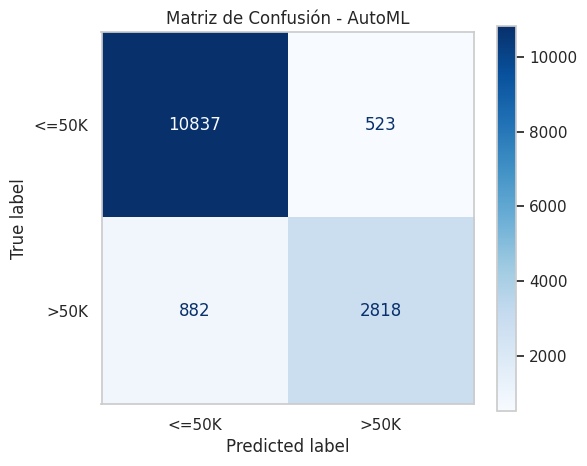

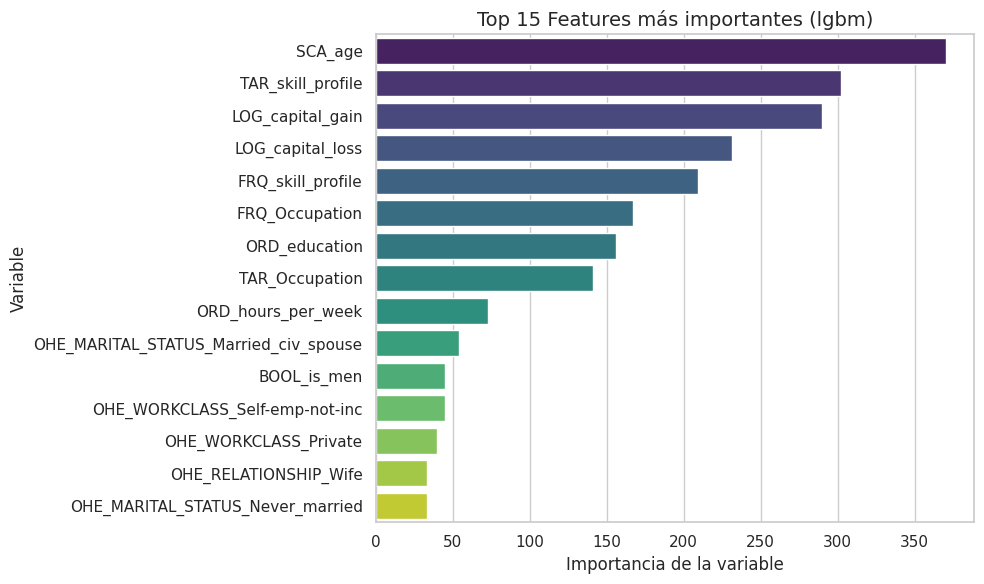

In [52]:
# !pip install flaml -q

from flaml import AutoML
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configurar y entrenar AutoML
automl = AutoML()

automl_settings = {
    "time_budget": 120,      # Tiempo máximo en segundos (puedes ajustarlo)
    "metric": 'accuracy',    # Métrica a optimizar
    "task": 'classification',
    "log_file_name": 'automl.log',
    "verbose": 1
}

print("Iniciando entrenamiento con AutoML...")
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

# 2. Resultados del mejor modelo
print("\n--- RESULTADOS DEL MEJOR MODELO ---")
print(f"Mejor algoritmo: {automl.best_estimator}")
print(f"Mejores hiperparámetros: {automl.best_config}")

# 3. Evaluación en Test
y_pred_automl = automl.predict(X_test)
acc_automl = accuracy_score(y_test, y_pred_automl)

print(f"\nAccuracy en Test: {acc_automl:.4f}\n")
print("Classification Report (AutoML):")
print(classification_report(y_test, y_pred_automl))

# 4. Matriz de Confusión
cm_automl = confusion_matrix(y_test, y_pred_automl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_automl, display_labels=['<=50K', '>50K'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - AutoML')
plt.grid(False)
plt.show()

# 5. Importancia de las variables
if hasattr(automl.model.estimator, 'feature_importances_'):
    importances = automl.model.estimator.feature_importances_
    features = X_train.columns
    imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    imp_df = imp_df.sort_values(by='Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis', ax=ax, hue='Feature', legend=False)
    ax.set_title(f'Top 15 Features más importantes ({automl.best_estimator})', fontsize=14)
    ax.set_xlabel('Importancia de la variable', fontsize=12)
    ax.set_ylabel('Variable', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("El modelo seleccionado por AutoML no soporta 'feature_importances_' directamente.")


- Accuracy: .91
- F1 Macro: .87

### Correlation

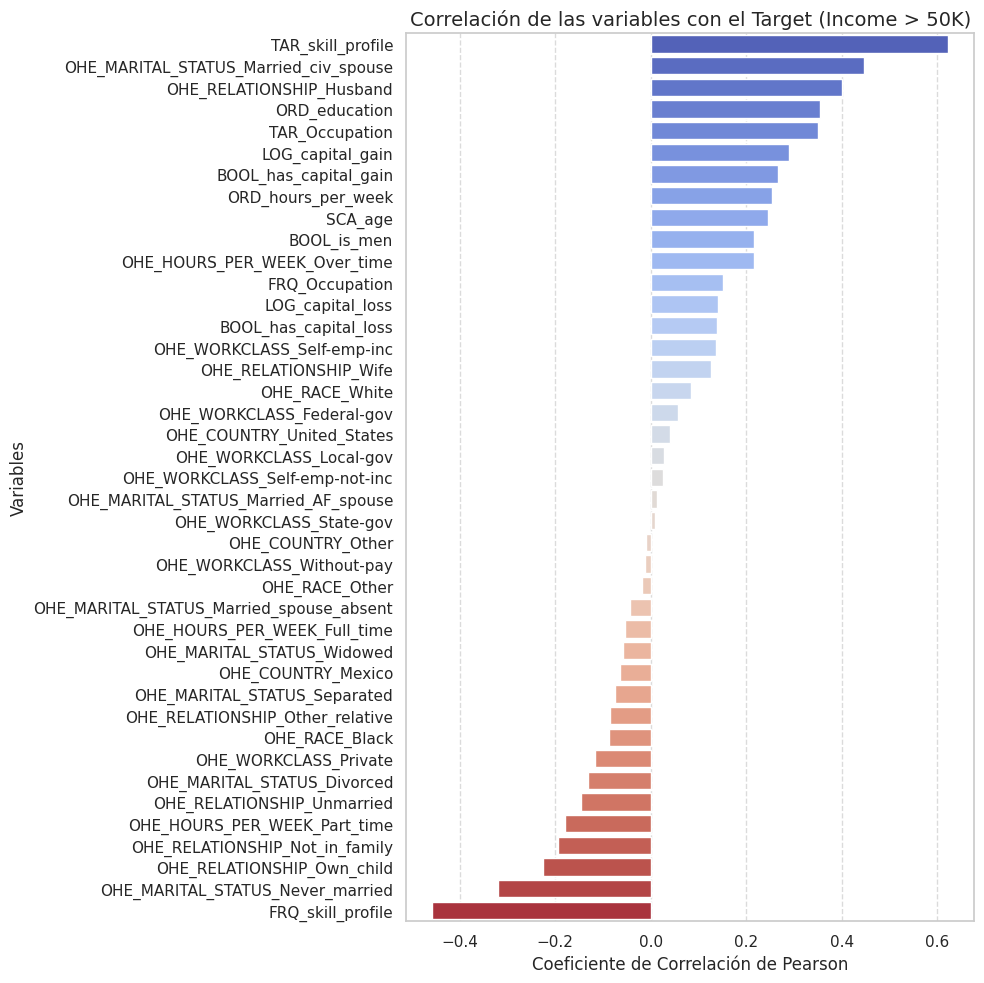

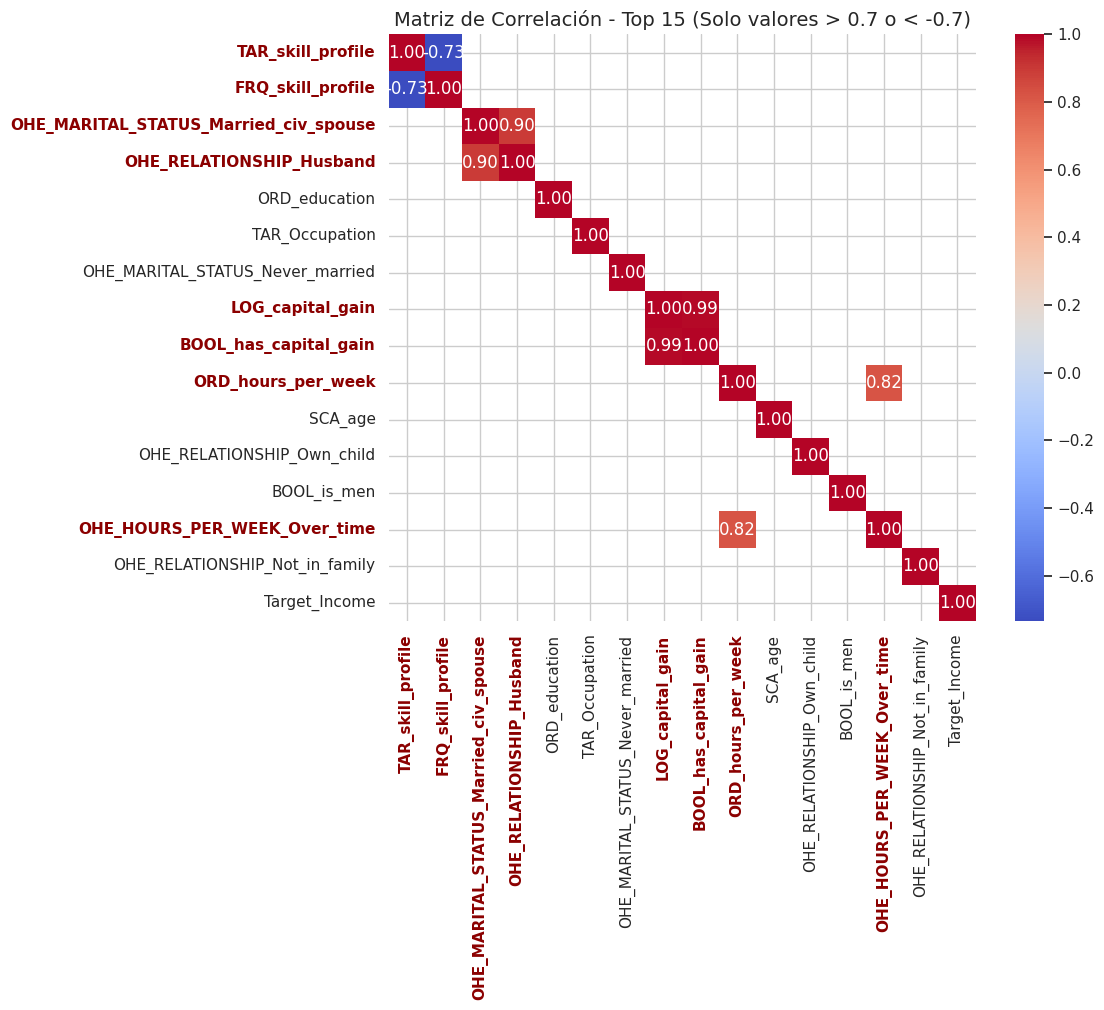

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Unir X_train y y_train temporalmente para calcular la correlación
df_corr = X_train.copy()
df_corr['Target_Income'] = y_train

# Calcular la matriz de correlación de Pearson
corr_matrix = df_corr.corr()

# 2. Extraer la correlación de todas las variables con respecto al Target
target_corr = corr_matrix['Target_Income'].drop('Target_Income').sort_values(ascending=False)

# Graficar la correlación con el Target
plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm', hue=target_corr.index, legend=False)
plt.title('Correlación de las variables con el Target (Income > 50K)', fontsize=14)
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Heatmap de correlación entre las top 15 variables más correlacionadas (en valor absoluto)
top_features = target_corr.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Target_Income') # Agregamos el target al final para el mapa

# Matriz de correlación reducida
corr_matrix_top = df_corr[top_features].corr()

# Crear máscara para ocultar correlaciones débiles (entre -0.7 y 0.7)
mask = (corr_matrix_top > -0.7) & (corr_matrix_top < 0.7)

# Identificar qué variables tienen al menos una correlación visible (excluyendo la diagonal)
mask_for_check = mask.copy()
np.fill_diagonal(mask_for_check.values, True) # Ignorar la diagonal
active_features = ~mask_for_check.all()

plt.figure(figsize=(12, 10))
ax = sns.heatmap(corr_matrix_top, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, mask=mask)
plt.title('Matriz de Correlación - Top 15 (Solo valores > 0.7 o < -0.7)', fontsize=14)

# Resaltar en rojo y negrita las etiquetas de las filas/columnas encendidas
for i, feature in enumerate(corr_matrix_top.columns):
    if active_features[feature]:
        ax.get_xticklabels()[i].set_color('darkred')
        ax.get_xticklabels()[i].set_weight('bold')
        ax.get_yticklabels()[i].set_color('darkred')
        ax.get_yticklabels()[i].set_weight('bold')

plt.tight_layout()
plt.show()


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.